In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR="/content/drive/MyDrive/openalex_enrich_out"
PAPERS_PATH=f"{OUT_DIR}/nips-papers_enriched_openalex.csv"
AUTHORS_PATH=f"{OUT_DIR}/nips-authors_unique_openalex.csv"

papers = pd.read_csv(PAPERS_PATH)
authors = pd.read_csv(AUTHORS_PATH)

print("papers:", papers.shape)
print("authors:", authors.shape)
papers.head(2)

Mounted at /content/drive
papers: (20326, 25)
authors: (67933, 7)


,src_index,year,title,oa_status,oa_http_status,oa_title_sim,oa_remaining_usd,oa_cost_usd,oa_reset_sec,hash_id,...,oa_cited_by_count,oa_primary_topic,oa_primary_topic_score,oa_domain,oa_field,oa_subfield,oa_topics_top5_json,oa_author_ids_json,oa_author_names_json,oa_author_positions_json
0,4451,2012,Iterative Thresholding Algorithm for Sparse In...,ok,200,1.0,0.902,0.001,29424,edfbe1afcf9246bb0d40eb4d8027d90f,...,73.0,Sparse and Compressive Sensing Techniques,0.9998,Physical Sciences,Engineering,Computational Mechanics,"[{""id"": ""https://openalex.org/T10500"", ""name"":...","[""https://openalex.org/A5077530909"", ""https://...","[""Dominique Guillot"", ""Bala Rajaratnam"", ""Benj...","[""first"", ""middle"", ""middle"", ""middle"", ""last""]"
1,4452,2012,Online allocation and homogeneous partitioning...,ok,200,1.0,0.901,0.001,29424,eeb69a3cb92300456b6a5f4162093851,...,1.0,Machine Learning and Algorithms,0.9999,Physical Sciences,Computer Science,Artificial Intelligence,"[{""id"": ""https://openalex.org/T12072"", ""name"":...","[""https://openalex.org/A5021658783"", ""https://...","[""Alexandra Carpentier"", ""Odalric-Ambrym Maill...","[""first"", ""last""]"


In [2]:
expected_papers = [
 'src_index','year','title','oa_status','oa_http_status','oa_title_sim',
 'oa_remaining_usd','oa_cost_usd','oa_reset_sec','hash_id','pdf_url',
 'oa_work_id','oa_display_name','oa_doi_url','oa_doi','oa_cited_by_count',
 'oa_primary_topic','oa_primary_topic_score','oa_domain','oa_field','oa_subfield',
 'oa_topics_top5_json','oa_author_ids_json','oa_author_names_json','oa_author_positions_json'
]
expected_authors = [
 'oa_author_id','year','author_name','orcid','institutions_json','raw_affiliation_strings_json','n_institutions'
]

missing_p = [c for c in expected_papers if c not in papers.columns]
missing_a = [c for c in expected_authors if c not in authors.columns]
print("Missing papers cols:", missing_p)
print("Missing authors cols:", missing_a)

print("papers src_index unique:", papers["src_index"].nunique(), "rows:", len(papers))
print("authors (author_id,year) unique:",
      authors.dropna(subset=["oa_author_id","year"]).drop_duplicates(["oa_author_id","year"]).shape[0],
      "rows:", len(authors))

dup_src = papers["src_index"].value_counts()
print("papers duplicated src_index rows:", int((dup_src > 1).sum()))

dup_ay = authors.groupby(["oa_author_id","year"]).size()
print("authors duplicated (author_id,year) rows:", int((dup_ay > 1).sum()))

Missing papers cols: []
Missing authors cols: []
papers src_index unique: 20326 rows: 20326
authors (author_id,year) unique: 67933 rows: 67933
papers duplicated src_index rows: 0
authors duplicated (author_id,year) rows: 0


In [3]:
papers["oa_status"].value_counts(dropna=False)

,count
oa_status,
ok,20322
ok_manual_doi,3
missing_in_openalex,1


In [6]:
status_by_year = papers.pivot_table(index="year", columns="oa_status", values="src_index", aggfunc="count", fill_value=0)
status_by_year.head(20)

oa_status,missing_in_openalex,ok,ok_manual_doi
year,,,
2012,0,370,0
2013,0,360,0
2014,0,411,0
2015,0,403,0
2016,0,568,0
2017,0,678,1
2018,0,1009,0
2019,0,1428,0
2020,0,1897,0


In [8]:
bad = papers[papers["oa_status"].isin(["no_match","no_match_low_sim"])][["src_index","year","title","oa_status"]].head(50)
err = papers[papers["oa_status"].astype(str).str.startswith("error_http_", na=False)][["src_index","year","title","oa_status","oa_http_status"]].head(50)
missing = papers[papers["oa_status"].isin(["missing_in_openalex"])][["src_index","year","title","oa_status","oa_doi_url"]].head(50)

bad, err, missing

(Empty DataFrame
 Columns: [src_index, year, title, oa_status]
 Index: [],
 Empty DataFrame
 Columns: [src_index, year, title, oa_status, oa_http_status]
 Index: [],
        src_index  year                                              title  \
 11075      15526  2022  Alleviating "Posterior Collapse'' in Deep Topi...   
 
                  oa_status                               oa_doi_url  
 11075  missing_in_openalex  https://doi.org/10.5555/3600270.3601909  )

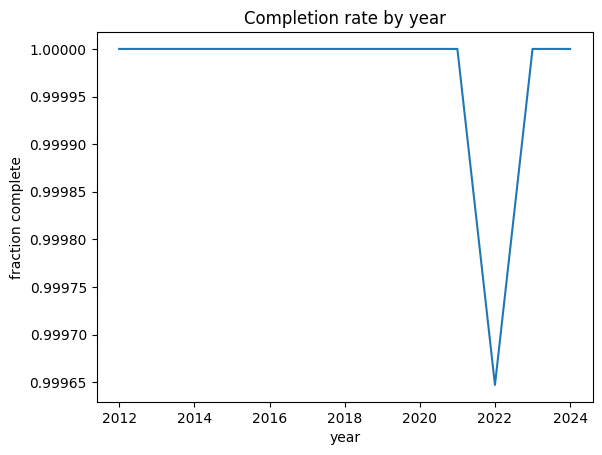

Overall completion rate: 0.9999508019285644


In [10]:
complete_status = {"ok","ok_fallback","ok_manual_doi"}
papers["is_complete"] = papers["oa_status"].isin(complete_status)

comp = papers.groupby("year")["is_complete"].mean().sort_index()
plt.figure()
plt.plot(comp.index, comp.values)
plt.title("Completion rate by year")
plt.xlabel("year"); plt.ylabel("fraction complete")
plt.show()

print("Overall completion rate:", papers["is_complete"].mean())

In [11]:
ok = papers[papers["oa_status"].isin(complete_status)].copy()
ok["oa_title_sim"] = pd.to_numeric(ok["oa_title_sim"], errors="coerce")

ok["oa_title_sim"].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])

,oa_title_sim
count,18771.000000
mean,0.998940
std,0.017542
min,0.208092
1%,0.987453
5%,1.000000
10%,1.000000
25%,1.000000
50%,1.000000
75%,1.000000


In [12]:
def frac_nonnull(df, col):
    return float(df[col].notna().mean()) if col in df.columns else None

metrics = pd.DataFrame([{
    "n_rows": len(papers),
    "complete_rate": papers["is_complete"].mean(),
    "doi_rate_all": frac_nonnull(papers, "oa_doi"),
    "doi_rate_complete": frac_nonnull(ok, "oa_doi"),
    "cited_by_rate_complete": frac_nonnull(ok, "oa_cited_by_count"),
    "primary_topic_rate_complete": frac_nonnull(ok, "oa_primary_topic"),
    "topics_top5_rate_complete": frac_nonnull(ok, "oa_topics_top5_json"),
    "author_ids_rate_complete": frac_nonnull(ok, "oa_author_ids_json"),
}])
metrics

,n_rows,complete_rate,doi_rate_all,doi_rate_complete,cited_by_rate_complete,primary_topic_rate_complete,topics_top5_rate_complete,author_ids_rate_complete
0,20326,0.999951,0.743235,0.743223,0.920246,0.804231,0.920246,0.920246


bad json ids: 0
bad json names: 0
bad json pos: 0
author list length mismatches: 0


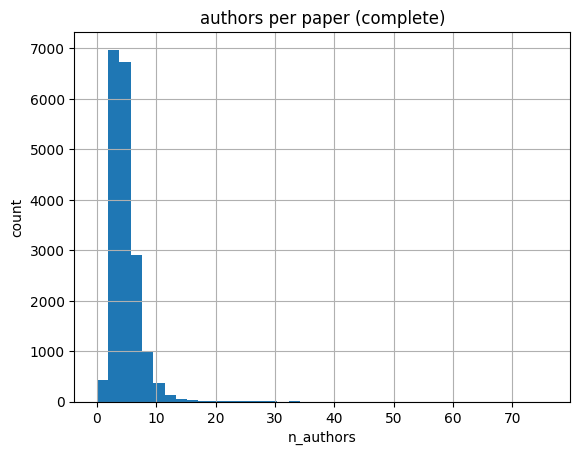

,src_index,year,title,n_authors


In [13]:
def parse_json_list(x):
    if pd.isna(x): return None
    try:
        v = json.loads(x)
        return v if isinstance(v, list) else None
    except:
        return None

ok2 = papers[papers["oa_status"].isin(complete_status)].copy()

ok2["ids"]  = ok2["oa_author_ids_json"].apply(parse_json_list)
ok2["names"]= ok2["oa_author_names_json"].apply(parse_json_list)
ok2["pos"]  = ok2["oa_author_positions_json"].apply(parse_json_list)

ok2["ids_bad_json"]   = ok2["oa_author_ids_json"].notna() & ok2["ids"].isna()
ok2["names_bad_json"] = ok2["oa_author_names_json"].notna() & ok2["names"].isna()
ok2["pos_bad_json"]   = ok2["oa_author_positions_json"].notna() & ok2["pos"].isna()

print("bad json ids:", int(ok2["ids_bad_json"].sum()))
print("bad json names:", int(ok2["names_bad_json"].sum()))
print("bad json pos:", int(ok2["pos_bad_json"].sum()))

ok2["n_authors"] = ok2["ids"].apply(lambda v: len(v) if isinstance(v,list) else np.nan)
ok2["len_mismatch"] = (
    ok2["ids"].apply(lambda v: len(v) if isinstance(v,list) else -1) !=
    ok2["names"].apply(lambda v: len(v) if isinstance(v,list) else -1)
) | (
    ok2["ids"].apply(lambda v: len(v) if isinstance(v,list) else -1) !=
    ok2["pos"].apply(lambda v: len(v) if isinstance(v,list) else -1)
)

print("author list length mismatches:", int(ok2["len_mismatch"].sum()))

plt.figure()
ok2["n_authors"].dropna().astype(int).hist(bins=40)
plt.title("authors per paper (complete)")
plt.xlabel("n_authors"); plt.ylabel("count")
plt.show()

ok2.loc[ok2["len_mismatch"], ["src_index","year","title","n_authors"]].head(20)

In [14]:
authors["year"] = pd.to_numeric(authors["year"], errors="coerce")
authors["n_institutions"] = pd.to_numeric(authors["n_institutions"], errors="coerce")

print("ORCID rate:", float(authors["orcid"].notna().mean()))
print("Has ≥1 institution rate:", float((authors["n_institutions"].fillna(0) >= 1).mean()))
print("Has raw affiliation strings rate:", float(authors["raw_affiliation_strings_json"].fillna("[]").ne("[]").mean()))

authors["n_institutions"].describe(percentiles=[.5,.9,.95,.99])

ORCID rate: 0.7123636524222395
Has ≥1 institution rate: 0.3463854091531362
Has raw affiliation strings rate: 0.3648594939131203


,n_institutions
count,67933.000000
mean,0.407004
std,0.648123
min,0.000000
50%,0.000000
90%,1.000000
95%,1.000000
99%,3.000000
max,11.000000


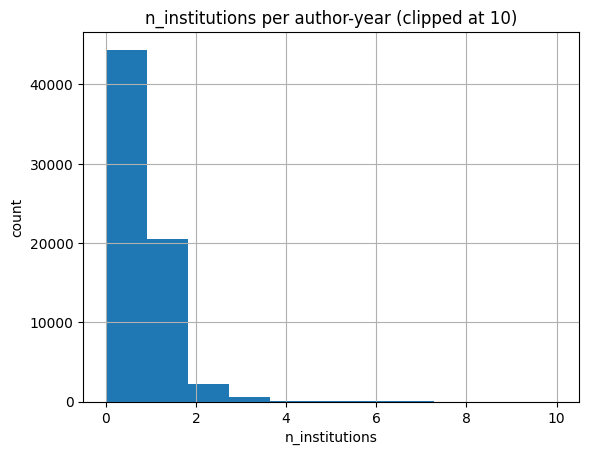

In [15]:
plt.figure()
authors["n_institutions"].fillna(0).astype(int).clip(upper=10).hist(bins=11)
plt.title("n_institutions per author-year (clipped at 10)")
plt.xlabel("n_institutions"); plt.ylabel("count")
plt.show()

In [16]:
pap = papers[papers["oa_status"].isin(complete_status)].copy()
pap["ids"] = pap["oa_author_ids_json"].apply(parse_json_list)
pap = pap[pap["ids"].notna()].copy()

paper_ay = (
    pap[["year","ids"]]
    .explode("ids")
    .rename(columns={"ids":"oa_author_id"})
    .dropna(subset=["oa_author_id","year"])
)
paper_ay["year"] = pd.to_numeric(paper_ay["year"], errors="coerce").astype(int)
paper_ay = paper_ay.drop_duplicates(["oa_author_id","year"])

auth_ay = authors.dropna(subset=["oa_author_id","year"]).copy()
auth_ay["year"] = pd.to_numeric(auth_ay["year"], errors="coerce").astype(int)
auth_ay = auth_ay.drop_duplicates(["oa_author_id","year"])

merged = paper_ay.merge(auth_ay[["oa_author_id","year"]], on=["oa_author_id","year"], how="left", indicator=True)
coverage = (merged["_merge"] == "both").mean()
print("paper author-year pairs covered by authors_df:", float(coverage))

missing_pairs = merged[merged["_merge"] != "both"].head(30)
missing_pairs

paper author-year pairs covered by authors_df: 0.9998969679128643


,year,oa_author_id,_merge
21563,2021,https://openalex.org/A5100405139,left_only
21564,2021,https://openalex.org/A5039125805,left_only
21565,2021,https://openalex.org/A5075033889,left_only
21566,2021,https://openalex.org/A5104208065,left_only
52060,2024,https://openalex.org/A5091260048,left_only
52061,2024,https://openalex.org/A5108954671,left_only
52062,2024,https://openalex.org/A5064907804,left_only


In [17]:
summary = {
  "papers_total": int(len(papers)),
  "papers_complete": int(papers["is_complete"].sum()),
  "papers_complete_rate": float(papers["is_complete"].mean()),
  "papers_status_counts": papers["oa_status"].value_counts(dropna=False).to_dict(),
  "complete_title_sim_p50": float(ok["oa_title_sim"].median()),
  "complete_title_sim_p10": float(ok["oa_title_sim"].quantile(0.10)),
  "complete_doi_rate": float(ok["oa_doi"].notna().mean()),
  "complete_topic_rate": float(ok["oa_primary_topic"].notna().mean()),
  "complete_authorlist_rate": float(ok["oa_author_ids_json"].notna().mean()),
  "authors_rows": int(len(authors)),
  "authors_orcid_rate": float(authors["orcid"].notna().mean()),
  "author_year_has_inst_rate": float((authors["n_institutions"].fillna(0) >= 1).mean()),
  "paper_author_year_coverage_in_authors_df": float(coverage),
}
pd.DataFrame([summary])

,papers_total,papers_complete,papers_complete_rate,papers_status_counts,complete_title_sim_p50,complete_title_sim_p10,complete_doi_rate,complete_topic_rate,complete_authorlist_rate,authors_rows,authors_orcid_rate,author_year_has_inst_rate,paper_author_year_coverage_in_authors_df
0,20326,20325,0.999951,"{'ok': 20322, 'ok_manual_doi': 3, 'missing_in_...",1.0,1.0,0.743223,0.804231,0.920246,67933,0.712364,0.346385,0.999897
